In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM
from Equipments.MCBOX import generate_test_voltages

from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


In [5]:
bias_channel = 11

In [23]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 1.6, bipolar = True, display = True) # changed from 2.8 V

Channel 11 has been set to 1.6 V.


In [6]:
agilent = Agilent.Agilent('TCPIP0::169.254.110.10::inst0::INSTR',power_limit = 0, freq_limit = 40e9)

Agilent Technologies, N5183A, MY47420242, A.01.43



In [7]:
pm = ThorlabsPM.ThorlabsPM('USB0::0x1313::0x807B::241023118::0::INSTR')

Thorlabs,PM16-130,241023118,1.6.0



In [ ]:
pm.readout(wavelength = 1064)

In [35]:
pm.readout(wavelength = 1064, average = 50)

8.5748667e-05

## agilent.set_frequency(frequency = 0.7e9)

## 700MHz

In [ ]:
agilent.set_frequency(frequency = 0.7e9)

output_power = []
RF_power_list = np.linspace(-30, 0, 31) # [dBm]
bias_list = np.linspace(-4,7,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064,average=50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
ps.Plot3D(x = RF_power_list+30, y = bias_list, Z = np.array(output_power),
          xlabel = "RF power after Amp (dBm) @ 700MHz", ylabel = "DC bias (V)", zlabel = "Output Power (W)",transpose=True)  

## 38GHz

RF_list_top = np.linspace(-14.5,-5,50)
RF_list_bot = np.linspace(-35,-15,20)
RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)
print(RF_power_list)

In [36]:
angle = 85.0 # [deg]
power = 1.6 # [mW]

output_power = []
RF_power_list = np.linspace(-20,-3,39) # [dBm]
#RF_list_top = np.linspace(-14.5,-5,50)
#RF_list_bot = np.linspace(-35,-15,20)
#RF_power_list = np.concatenate((RF_list_bot,RF_list_top), axis=0)

bias_list = np.linspace(-10,10,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_frequency(frequency = 38.0e9)  # changed from 10 GHz
agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power} dBm")
    agilent.set_power(RF_power)
    time.sleep(0.1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064, average = 50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

[-20.         -19.55263158 -19.10526316 -18.65789474 -18.21052632
 -17.76315789 -17.31578947 -16.86842105 -16.42105263 -15.97368421
 -15.52631579 -15.07894737 -14.63157895 -14.18421053 -13.73684211
 -13.28947368 -12.84210526 -12.39473684 -11.94736842 -11.5
 -11.05263158 -10.60526316 -10.15789474  -9.71052632  -9.26315789
  -8.81578947  -8.36842105  -7.92105263  -7.47368421  -7.02631579
  -6.57894737  -6.13157895  -5.68421053  -5.23684211  -4.78947368
  -4.34210526  -3.89473684  -3.44736842  -3.        ]
[-10.   -9.5  -9.   -8.5  -8.   -7.5  -7.   -6.5  -6.   -5.5  -5.   -4.5
  -4.   -3.5  -3.   -2.5  -2.   -1.5  -1.   -0.5   0.    0.5   1.    1.5
   2.    2.5   3.    3.5   4.    4.5   5.    5.5   6.    6.5   7.    7.5
   8.    8.5   9.    9.5  10. ]
Now checking -20.0 dBm
[0.00011203083, 0.00010519541, 0.00018627447, 0.00024984326, 0.00018341502, 7.3808362e-05, 8.7352586e-05, 0.00020667574, 0.00024835544, 0.00014390575, 4.248579e-05, 0.0001067544, 0.00020493232, 0.00019140434, 7.149006

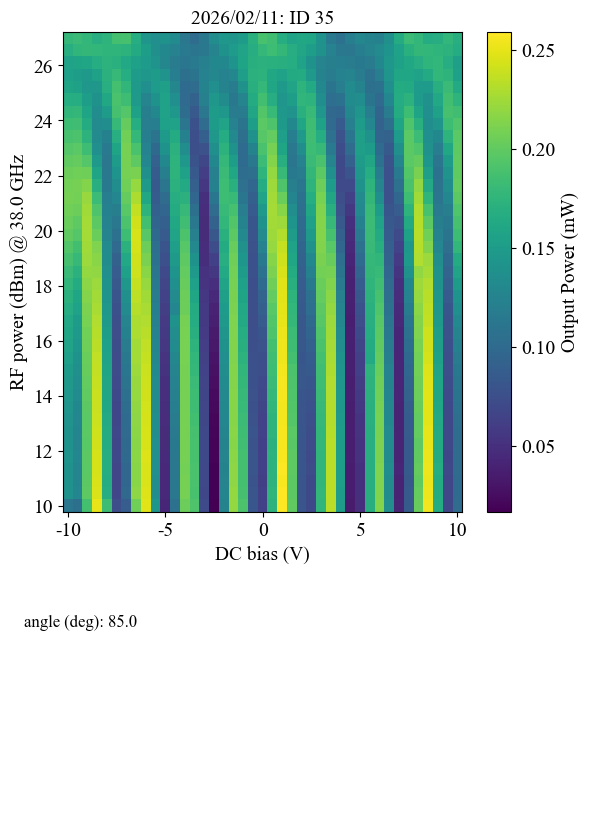

In [37]:
ps.Plot3D(x = RF_power_list + 30, y = bias_list, Z = np.array(output_power)*1e+3,
          xlabel = "RF power (dBm) @ 38.0 GHz", ylabel = "DC bias (V)", zlabel = "Output Power (mW)", transpose = True, notes = {"angle (deg)": angle})  

In [ ]:
pm.close()

In [ ]:
agilent.close()

In [ ]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
rm.list_opened_resources()

In [ ]:
rm.close()

## Check the polarization

In [10]:
def func(x,a,b,c,d):
    return a*np.sin(b*x+c)+d

In [38]:
bias_list = np.linspace(-10,10,251) # [V]
transmission = []

for bias in bias_list:
    mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
    power = pm.readout(wavelength = 1064,average=50)
    transmission.append(power)

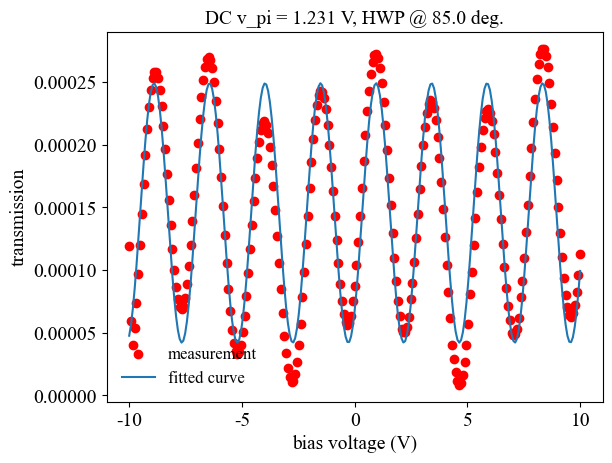

In [39]:
initial_guess = [0.002,2.5,0,0]

popt1, pcov1 = curve_fit(
            func, bias_list, transmission,p0=initial_guess,maxfev=10000000,method='lm'
        )

# popt1, pcov1 = curve_fit(
#             func, bias_list, transmission,maxfev=10000000,method='lm'
#         )

plt.figure()
plt.scatter(bias_list,np.array(transmission),c = "r",label = "measurement")
plt.plot(bias_list,func(bias_list,*popt1), label = "fitted curve")
plt.xlabel('bias voltage (V)')
plt.ylabel("transmission")
plt.title(f"DC v_pi = {round(np.pi/popt1[1],3)} V, HWP @ {angle} deg.")
plt.legend()
plt.show()

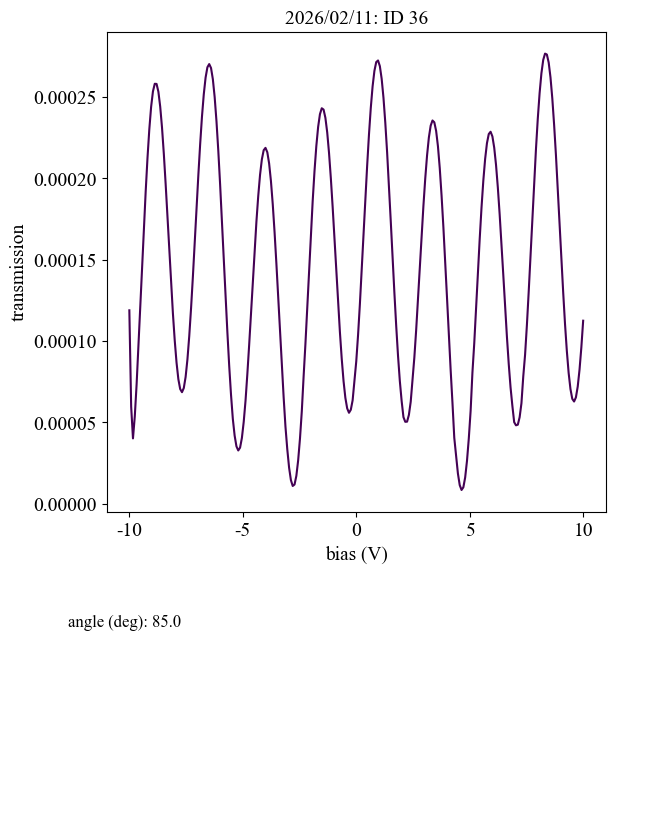

In [40]:
ps.Plot2D(x = bias_list, y = None, Z=transmission, xlabel='bias (V)', ylabel='Y', zlabel='transmission',notes = {"angle (deg)": angle})

In [ ]:
print(len(bias_list))
print(len(transmission))

## test the degrade for RF

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
transimission_intensity = np.array([5.8,])
voltage = np.array([-4,-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,])

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
def func(x,a,b,c):
    return a*np.sin(b*x)+c

popt1, pcov1 = curve_fit(
            func, voltage, transimission_intensity,maxfev=100000,
        )

In [ ]:
popt1

In [ ]:
plt.plot(voltage, func(voltage,*popt1))